In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

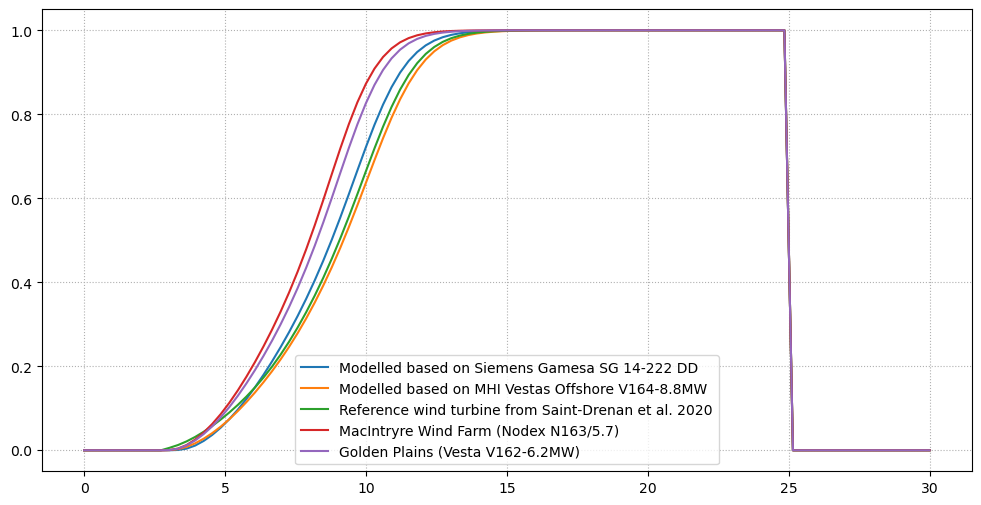

In [2]:
from sea_breeze_analysis.wind_turbine_power_curve import GenericWindTurbinePowerCurve, iea_ref_10mw

x = np.linspace(0,30,100)

plt.figure(figsize=[12,6])

Pnom=14000
D=222
plt.plot(x,GenericWindTurbinePowerCurve(x,Pnom,D)/Pnom,label="Modelled based on Siemens Gamesa SG 14-222 DD")

Pnom=8800
D=164
plt.plot(x,GenericWindTurbinePowerCurve(x,Pnom,D)/Pnom,label="Modelled based on MHI Vestas Offshore V164-8.8MW")

Pnom=2000
D=80
plt.plot(x,GenericWindTurbinePowerCurve(x,Pnom,D)/Pnom,label="Reference wind turbine from Saint-Drenan et al. 2020")


Pnom=5700
D=163
plt.plot(x,GenericWindTurbinePowerCurve(x,Pnom,D)/Pnom,label="MacIntryre Wind Farm (Nodex N163/5.7)")


Pnom=6200
D=162
plt.plot(x,GenericWindTurbinePowerCurve(x,Pnom,D)/Pnom,label="Golden Plains (Vesta V162-6.2MW)")

# Pnom=10000
# D=180
# plt.plot(x,GenericWindTurbinePowerCurve(x,Pnom,D)/Pnom)


plt.gca().grid(ls=":")
plt.legend()

In [7]:
import pandas as pd
df = pd.read_table("/home/548/ab4502/performance_ccblade.dat")
df.columns

Index(['# Wind speed (m/s) ', ' Rotor rotational speed (rpm) ',
       ' Pitch angle (deg) ', ' Rotor electrical power (W) ',
       ' Rotor aerodynamic power (W) ', ' Rotor thrust (N) ',
       ' Rotor aerodynamic torque (Nm) ', ' Blade root flapwise moment (Nm)',
       ' Rotor electrical power coefficient (-) ',
       ' Rotor aerodynamic power coefficient (-) ',
       ' Rotor thrust coefficient (-) ',
       ' Rotor aerodynamic torque coefficient'],
      dtype='object')

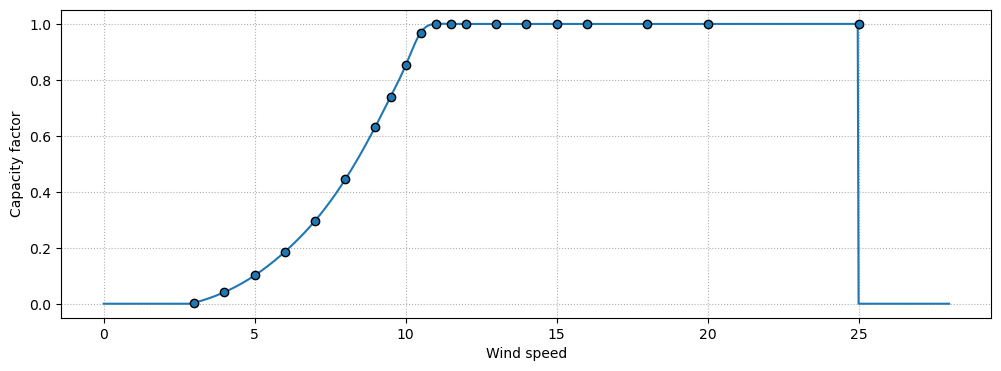

In [25]:
x = [3, 4, 5, 6, 7, 8, 9, 9.5, 10, 10.5, 11, 11.5, 12, 13, 14, 15, 16, 18, 20, 25]
generic_curve = np.array([37.874, 440.49, 1074.369, 1973.429, 3152.143, 4723.686, 6734.924,
7863.971, 9057.796, 10309.687, 10638.3, 10638.3, 10638.3, 10638.3, 10638.3, 10638.3, 10638.3, 10638.3, 10638.3, 10638.301])
ws = np.linspace(0,28,1000)
cf = iea_ref_10mw(ws) / 10638.301

plt.figure(figsize=[12,4])
plt.plot(ws,cf)
plt.plot(x,generic_curve/10638.301, marker="o",color="tab:blue",ls="none",mfc="tab:blue",ms=6,mec="k")

plt.ylabel("Capacity factor")
plt.xlabel("Wind speed")
plt.gca().grid(ls=":")

#plt.plot(df['# Wind speed (m/s) '], df[' Rotor electrical power (W) '] / df[' Rotor electrical power (W) '].max(),ls="none", marker="x")
#plt.plot(df['# Wind speed (m/s) '], df[' Rotor aerodynamic power (W) '] / df[' Rotor aerodynamic power (W) '].max(),ls="none", marker="o",mfc="none")

plt.savefig("/g/data/ng72/ab4502/figs/wind_energy_paper/power_curve.jpeg",bbox_inches="tight",dpi=300)

In [4]:
from sea_breeze_analysis.wind_turbine_power_curve import capacity_factor

Pnom=5700
D=163
plt.plot(x,GenericWindTurbinePowerCurve(x,Pnom,D)/Pnom,label="MacIntryre Wind Farm (Nodex N163/5.7)",lw=4)
plt.plot(x,capacity_factor(x,Pnom=Pnom,D=D),label="Logistic fit",lw=2)
plt.legend()
plt.gca().grid(ls=":")

AttributeError: 'list' object has no attribute 'shape'

In [4]:
from sea_breeze_analysis.wind_turbine_power_curve import *

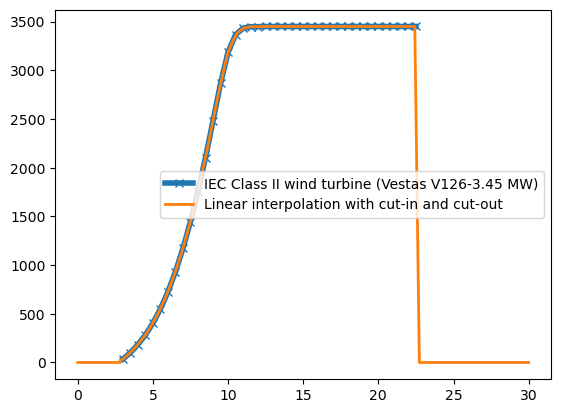

In [17]:
plt.plot(
    np.arange(3,23,0.5),
    np.array([35,101,184,283,404,550,725,932,1172,1446,1760,2104,2482,2865,3187,3366,3433,
                    3448,3448,3450,3450,3450,3450,3450,3450,3450,3450,3450,3450,3450,3450,3450,3450,3450,3450,3450,3450,3450,
                    3450,3450]),
    label="IEC Class II wind turbine (Vestas V126-3.45 MW)",
    lw=4,color="tab:blue",marker="x")

plt.plot(x,iec_class2(x),label="Linear interpolation with cut-in and cut-out",lw=2,color="tab:orange")
plt.legend()